# EDA Triagegeist - MIMIC-IV-ED - FULL DATASET

from https://physionet.org/content/mimic-iv-ed-demo/2.2/

metadata available at https://mimic.mit.edu/docs/iv/modules/ed/

## Index

- [Imports](#imports)
- [Load and Merge Data](#load-and-merge-data)
- [Data Preparation](#data-preparation)
- [Distributions by Variable Type](#distributions-by-variable-type)
- [Missing Data Matrix](#missing-data-matrix)
- [Correlation Matrix](#correlation-matrix)
- [KMeans Clustering (k=5)](#kmeans-clustering-k5)

## Imports

In [36]:
#Run once if needed
#%pip install pandas seaborn matplotlib scikit-learn scipy google-cloud-bigquery db-dtypes

In [90]:
import warnings

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from scipy.stats import pearsonr, spearmanr
from google.cloud import bigquery
from google.auth.exceptions import DefaultCredentialsError
from google.api_core.exceptions import Forbidden
from google.oauth2 import service_account

SEED = 42

# Global warning control for notebook outputs.
SUPPRESS_PACKAGE_WARNINGS = True
if SUPPRESS_PACKAGE_WARNINGS:
    warnings.filterwarnings("ignore", category=FutureWarning)
    warnings.filterwarnings("ignore", category=DeprecationWarning)
    warnings.filterwarnings("ignore", category=UserWarning, module="seaborn")

# Color mapping for acuity levels used across the notebook.
ACUITY_LEVELS = [1, 2, 3, 4, 5]
ACUITY_COLORS_INT = {1: "red", 2: "orange", 3: "yellow", 4: "green", 5: "blue"}
ACUITY_COLORS_STR = {str(k): v for k, v in ACUITY_COLORS_INT.items()}

# Use YOUR project for BigQuery billing/query jobs (not the public dataset project)
BQ_BILLING_PROJECT = "triagegeist"  # e.g., "my-gcp-project-with-billing"

# Optional: local service account JSON path (alternative to gcloud ADC login)
SERVICE_ACCOUNT_JSON = None  # e.g., r"C:\keys\my-service-account.json"

## Load and Merge Data

In [ ]:
# Query real data from MIMIC-IV-ED public dataset (BigQuery)
ED_TRIAGE_QUERY = """
WITH ed_triage AS (
  SELECT 
    e.stay_id,
    e.subject_id,
    e.intime,
    e.gender,
    e.race,
    e.arrival_transport,
    t.temperature,
    t.heartrate,
    t.resprate,
    t.o2sat,
    t.sbp,
    t.dbp,
    t.pain,
    t.acuity,
    t.chiefcomplaint
  FROM 
`physionet-data.mimiciv_ed.edstays` e
  LEFT JOIN 
`physionet-data.mimiciv_ed.triage` t ON e.stay_id=t.stay_id 

)

SELECT *
FROM ed_triage
WHERE acuity IS NOT NULL
"""

try:
    if SERVICE_ACCOUNT_JSON:
        creds = service_account.Credentials.from_service_account_file(SERVICE_ACCOUNT_JSON)
        billing_project = BQ_BILLING_PROJECT or creds.project_id
        client = bigquery.Client(project=billing_project, credentials=creds)
    else:
        client = (
            bigquery.Client(project=BQ_BILLING_PROJECT)
            if BQ_BILLING_PROJECT
            else bigquery.Client()
        )

    df_triage_edstay = client.query(ED_TRIAGE_QUERY).result().to_dataframe(
        create_bqstorage_client=False
    )

    print("df_triage_edstay shape:", df_triage_edstay.shape)
    df_triage_edstay.tail()  # head() has many missing values

except DefaultCredentialsError as exc:
    raise RuntimeError(
        "Google credentials not found. Choose ONE option:\n"
        "1) Install Google Cloud SDK and run: gcloud auth application-default login\n"
        "2) Set SERVICE_ACCOUNT_JSON in the imports cell with a valid key file path\n"
        "Also set BQ_BILLING_PROJECT to your own project with billing enabled."
    ) from exc

except Forbidden as exc:
    raise RuntimeError(
        "BigQuery access/billing error.\n"
        "Use your own billing project in BQ_BILLING_PROJECT, with BigQuery API and billing enabled.\n"
        "Keep reading data from `physionet-data.mimiciv_ed` tables in the SQL."
    ) from exc

df_triage_edstay shape: (418100, 15)


In [39]:
# Overview: schema and summary statistics
df_triage_edstay.info()
df_triage_edstay.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418100 entries, 0 to 418099
Data columns (total 15 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   stay_id            418100 non-null  Int64         
 1   subject_id         418100 non-null  Int64         
 2   intime             418100 non-null  datetime64[us]
 3   gender             418100 non-null  object        
 4   race               418100 non-null  object        
 5   arrival_transport  418100 non-null  object        
 6   temperature        401502 non-null  object        
 7   heartrate          407813 non-null  object        
 8   resprate           404555 non-null  object        
 9   o2sat              404308 non-null  object        
 10  sbp                406617 non-null  object        
 11  dbp                405817 non-null  object        
 12  pain               411948 non-null  object        
 13  acuity             418100 non-null  object  

,stay_id,subject_id,intime
count,418100.0,418100.0,418100
mean,34997634.798491,15008968.758493,2156-06-06 17:46:50.349629
min,30000012.0,10000032.0,2110-01-11 01:45:00
25%,32499351.75,12519662.75,2136-05-26 19:19:30
50%,34993576.5,15015775.0,2156-05-28 11:14:00
75%,37503905.25,17498880.5,2176-07-13 14:38:45
max,39999965.0,19999914.0,2212-04-05 23:23:00
std,2887965.896794,2878121.705045,NaN


## Data Preparation

1. separado de acordo com tipo q deveria ser
2. processado para type desejado

    2.1. para data foi escolhido o formato %Y-%m-%d %H:%M:%S

    2.2. temperatura convertida para Celsius (°C)

3. definir minimo e max pras variaveis de sinais vitais, exploracao de outliers 


 Foram excluidas variaveis que nao sao possiveis obter na entrada da emergencia como hora de saida e disposition (forma de saida ex: internacao, casa...)

In [40]:
# --- Column classification by expected dtype ---

id_columns = ["subject_id", "stay_id"]

categorical_columns = ["gender", "race", "arrival_transport"]

string_columns = ["chiefcomplaint"] # free-text chief complaint at triage (e.g., "chest pain", "shortness of breath", etc.)

datetime_columns = ["intime"] # ED arrival time 

continuous_columns = ["temperature"]

int_columns = [
    "resprate",
    "heartrate",
    "o2sat",
    "pain",
    "sbp",   # systolic blood pressure
    "dbp",   # diastolic blood pressure
]

target_column = ["acuity"] # target variable: 1 (most urgent) to 5 (least urgent) assigned by triage nurse based on initial assessment

In [41]:
# --- Apply dtype conversions ---

DATETIME_FMT = "%Y-%m-%d %H:%M:%S"  # 24-hour (military) format

# IDs & integers -> nullable integer
for col in id_columns + int_columns:
    df_triage_edstay[col] = (
        pd.to_numeric(df_triage_edstay[col], errors="coerce")
        .round()
        .astype("Int64")
    )

# Continuous -> float64
for col in continuous_columns:
    df_triage_edstay[col] = pd.to_numeric(df_triage_edstay[col], errors="coerce").astype("float64")

# Convert temperature from Fahrenheit to Celsius
if "temperature" in df_triage_edstay.columns:
    df_triage_edstay["temperature"] = ((df_triage_edstay["temperature"] - 32) * 5 / 9).round(2)

# Categorical
for col in categorical_columns:
    df_triage_edstay[col] = df_triage_edstay[col].astype("category")

# Free-text
for col in string_columns:
    df_triage_edstay[col] = df_triage_edstay[col].astype("string")

# Datetime (24h military format)
for col in datetime_columns:
    df_triage_edstay[col] = (
        pd.to_datetime(df_triage_edstay[col], format=DATETIME_FMT, errors="coerce")
        .dt.floor("s")
    )

# Keep backward-compatible alias
df = df_triage_edstay

# Preview datetime columns in military format
preview = df[datetime_columns].head(3).copy()
for col in datetime_columns:
    preview[col] = preview[col].dt.strftime(DATETIME_FMT)

print("Datetime preview (YYYY-MM-DD HH:MM:SS, 24h):")
print(preview)
print("\nTemperature preview in Celsius (°C):")
print(df["temperature"].head())
print("\nFinal dtypes:")
print(df.dtypes)

Datetime preview (YYYY-MM-DD HH:MM:SS, 24h):
                intime
0  2142-12-30 09:12:00
1  2129-05-27 15:39:00
2  2158-10-03 07:17:00

Temperature preview in Celsius (°C):
0    35.67
1    38.00
2    35.61
3    37.89
4    39.11
Name: temperature, dtype: float64

Final dtypes:
stay_id                       Int64
subject_id                    Int64
intime               datetime64[us]
gender                     category
race                       category
arrival_transport          category
temperature                 float64
heartrate                     Int64
resprate                      Int64
o2sat                         Int64
sbp                           Int64
dbp                           Int64
pain                          Int64
acuity                       object
chiefcomplaint       string[python]
dtype: object


In [66]:
# define min and max for numerical columns and flag outliers (e.g., using IQR method)
numerical_columns = continuous_columns + int_columns
for col in numerical_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 3 * IQR
    upper_bound = Q3 + 3 * IQR
    df[f"{col}_outlier"] = ((df[col] < lower_bound) | (df[col] > upper_bound)).astype("boolean")
    

In [67]:
#count of outliers in each numerical column
outlier_counts = {col: df[f"{col}_outlier"].sum() for col in numerical_columns}
print("Outlier counts by column:")
for col, count in outlier_counts.items():
    print(f"{col}: {count}")

Outlier counts by column:
temperature: 3209
resprate: 4988
heartrate: 216
o2sat: 1098
pain: 49
sbp: 467
dbp: 745


In [84]:
# Clinical sanity checks for vital signs (post conversion to Celsius)
VITAL_SANITY_RULES = {
    "temperature": {"hard_min": 20.0, "hard_max": 45.0, "soft_min": 34.0, "soft_max": 41.0, "unit": "C"},
    "heartrate": {"hard_min": 0, "hard_max": 300, "soft_min": 40, "soft_max": 220, "unit": "bpm"},
    "resprate": {"hard_min": 4, "hard_max": 80, "soft_min": 8, "soft_max": 40, "unit": "breaths/min"},
    "o2sat": {"hard_min": 50, "hard_max": 100, "soft_min": 75, "soft_max": 100, "unit": "pct"},
    "sbp": {"hard_min": 0, "hard_max": 400, "soft_min": 70, "soft_max": 220, "unit": "mmHg"},
    "dbp": {"hard_min": 0, "hard_max": 300, "soft_min": 40, "soft_max":250, "unit": "mmHg"},
    "pain": {"hard_min": -1, "hard_max": 10, "soft_min": 0, "soft_max": 10, "unit": "score"},
}

sanity_rows = []
hard_flag_cols = []

for col, rule in VITAL_SANITY_RULES.items():
    if col not in df.columns:
        continue

    values = pd.to_numeric(df[col], errors="coerce")
    hard_fail = values.notna() & ((values < rule["hard_min"]) | (values > rule["hard_max"]))
    soft_alert = values.notna() & ~hard_fail & (
        (values < rule["soft_min"]) | (values > rule["soft_max"])
    )

    hard_col = f"{col}_sanity_hard_fail"
    soft_col = f"{col}_sanity_soft_alert"
    df[hard_col] = hard_fail.astype("boolean")
    df[soft_col] = soft_alert.astype("boolean")
    hard_flag_cols.append(hard_col)

    sanity_rows.append(
        {
            "variable": col,
            "unit": rule["unit"],
            "hard_range": f"[{rule['hard_min']}, {rule['hard_max']}]",
            "soft_range": f"[{rule['soft_min']}, {rule['soft_max']}]",
            "hard_fail_n": int(hard_fail.sum()),
            "hard_fail_pct": round(float(hard_fail.mean() * 100), 3),
            "soft_alert_n": int(soft_alert.sum()),
            "soft_alert_pct": round(float(soft_alert.mean() * 100), 3),
        }
    )

sanity_summary = (
    pd.DataFrame(sanity_rows)
    .sort_values(["hard_fail_n", "soft_alert_n"], ascending=False)
    .reset_index(drop=True)
)

print("Sanity check summary for vital signs:")
display(sanity_summary)

if hard_flag_cols:
    rows_with_hard_fail = int(df[hard_flag_cols].fillna(False).any(axis=1).sum())
    print(f"Rows with at least one hard fail: {rows_with_hard_fail}")

Sanity check summary for vital signs:


,variable,unit,hard_range,soft_range,hard_fail_n,hard_fail_pct,soft_alert_n,soft_alert_pct
0,pain,score,"[-1, 10]","[0, 10]",11162,2.677,2,0.000
1,dbp,mmHg,"[0, 300]","[40, 250]",0,0.000,1844,0.442
2,sbp,mmHg,"[0, 400]","[70, 220]",0,0.000,1072,0.257
3,heartrate,bpm,"[0, 300]","[40, 220]",0,0.000,497,0.119
4,temperature,C,"[20.0, 45.0]","[34.0, 41.0]",0,0.000,193,0.046
5,resprate,breaths/min,"[4, 80]","[8, 40]",0,0.000,126,0.030
6,o2sat,pct,"[50, 100]","[75, 100]",0,0.000,101,0.024


Rows with at least one hard fail: 11162


In [99]:
# Drop rows with at least one hard fail from clinical sanity rules.
if hard_flag_cols:
    df = df[~df[hard_flag_cols].fillna(False).any(axis=1)].copy()

# Drop temporary quality-control flag columns.
flag_cols_to_drop = [
    col
    for col in df.columns
    if col.endswith("_outlier")
    or col.endswith("_sanity_hard_fail")
    or col.endswith("_sanity_soft_alert")
]
if flag_cols_to_drop:
    df = df.drop(columns=flag_cols_to_drop)

print(f"Dropped {len(flag_cols_to_drop)} flag columns.")
print(f"Data shape after dropping rows with hard fails: {df.shape}")

Dropped 21 flag columns.
Data shape after dropping rows with hard fails: (405824, 16)


In [88]:
df.describe()

,stay_id,subject_id,intime,temperature,heartrate,resprate,o2sat,sbp,dbp,pain,kmeans_5
count,405824.0,405824.0,405824,390320.000000,396115.0,393067.0,392794.0,394938.0,394179.0,384577.0,405824.0
mean,34997642.814314,15009399.271369,2156-06-01 16:05:51.879782,36.712856,85.06153,17.534474,98.414092,134.962698,77.541787,4.16812,0.470406
min,30000012.0,10000032.0,2110-01-11 01:45:00,20.720000,1.0,4.0,50.0,1.0,0.0,-1.0,0.0
25%,32499939.0,12520969.5,2136-05-19 18:29:00,36.390000,72.0,16.0,97.0,120.0,68.0,0.0,0.0
50%,34995524.5,15015154.0,2156-05-25 05:35:30,36.670000,84.0,18.0,99.0,133.0,77.0,4.0,0.0
75%,37503508.5,17501094.0,2176-07-08 16:38:30,37.000000,96.0,18.0,100.0,148.0,87.0,8.0,1.0
max,39999965.0,19999914.0,2212-04-05 23:23:00,44.110000,256.0,80.0,100.0,312.0,298.0,10.0,1.0
std,2887749.662355,2878713.740156,NaN,0.547868,17.641047,2.297006,2.040686,22.332069,14.814674,3.754355,0.499124


## Distributions by Variable Type
### Reusable plotting utilities

Categorical columns: ['gender', 'race', 'arrival_transport']
Integer columns: ['resprate', 'heartrate', 'o2sat', 'pain', 'sbp', 'dbp', 'acuity']
Float columns: ['temperature']


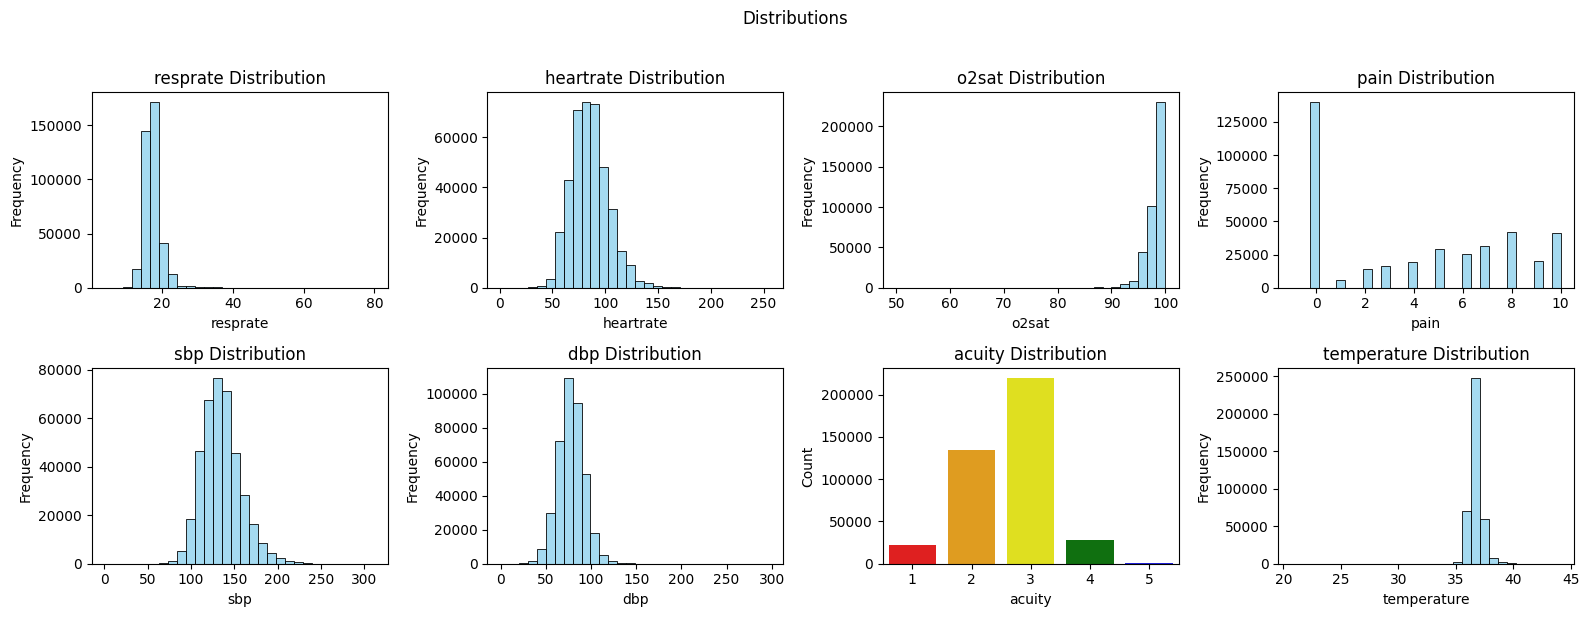

In [98]:
# Shared plotting helpers to keep downstream cells short and consistent.

def get_plot_column_groups(dataframe):
    """Return column groups used across distribution and boxplot cells."""
    target_cols = target_column if "target_column" in globals() else []

    categorical_cols = [col for col in categorical_columns if col in dataframe.columns]
    integer_cols = [col for col in (int_columns + target_cols) if col in dataframe.columns]
    float_cols = [col for col in continuous_columns if col in dataframe.columns]
    numeric_plot_cols = [col for col in (integer_cols + float_cols) if col not in id_columns]

    return categorical_cols, integer_cols, float_cols, numeric_plot_cols


def remove_extreme_outliers_iqr(dataframe, value_col, k=3.0):
    """Return rows where value_col is inside [Q1 - k*IQR, Q3 + k*IQR]."""
    if value_col not in dataframe.columns:
        return dataframe.copy()

    series = pd.to_numeric(dataframe[value_col], errors="coerce")
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1

    if pd.isna(iqr) or iqr == 0:
        return dataframe[series.notna()].copy()

    lower = q1 - k * iqr
    upper = q3 + k * iqr
    return dataframe[(series >= lower) & (series <= upper)].copy()


def get_acuity_order(observed_values):
    """Order acuity values using the global 1->5 convention."""
    observed = (
        pd.to_numeric(pd.Series(observed_values), errors="coerce")
        .dropna()
        .round()
        .astype(int)
    )
    observed_levels = set(observed.tolist())
    return [level for level in ACUITY_LEVELS if level in observed_levels]


def plot_numeric_distributions(
    dataframe,
    columns,
    target_col="acuity",
    remove_outliers=False,
    outlier_k=3.0,
    bins=30,
    cols_per_row=4,
):
    valid_cols = [col for col in columns if col in dataframe.columns]
    if not valid_cols:
        print("No valid columns found for distribution plots.")
        return

    n_rows = (len(valid_cols) + cols_per_row - 1) // cols_per_row
    fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(4 * cols_per_row, 3 * n_rows))
    axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

    for i, col in enumerate(valid_cols):
        ax = axes[i]
        col_df = dataframe[[col]].dropna().copy()

        if col_df.empty:
            ax.set_visible(False)
            continue

        if col == target_col:
            # Normalize acuity to integer classes so order/palette always match categories.
            col_df[col] = pd.to_numeric(col_df[col], errors="coerce").round().astype("Int64")
            col_df = col_df.dropna(subset=[col]).copy()
            if col_df.empty:
                ax.set_visible(False)
                continue

            observed_acuity = set(col_df[col].astype(int).unique().tolist())
            acuity_order = [level for level in ACUITY_LEVELS if level in observed_acuity]
            if acuity_order:
                acuity_palette = [ACUITY_COLORS_INT[level] for level in acuity_order]
            else:
                acuity_order = sorted(col_df[col].astype(int).unique().tolist())
                acuity_palette = "Set2"

            sns.countplot(
                data=col_df,
                x=col,
                order=acuity_order,
                hue=col,
                palette=acuity_palette,
                legend=False,
                ax=ax,
            )
            ax.set_ylabel("Count")
        else:
            if remove_outliers:
                col_df = remove_extreme_outliers_iqr(col_df, col, k=outlier_k)

            if col_df.empty:
                ax.set_visible(False)
                continue

            sns.histplot(
                col_df[col],
                bins=bins,
                kde=False,
                color="skyblue",
                edgecolor="black",
                ax=ax,
            )
            ax.set_ylabel("Frequency")

        ax.set_title(f"{col} Distribution")
        ax.set_xlabel(col)

    for j in range(len(valid_cols), len(axes)):
        axes[j].set_visible(False)

    suffix = " (outliers removed)" if remove_outliers else ""
    plt.suptitle(f"Distributions{suffix}", y=1.02)
    plt.tight_layout()
    plt.show()


def plot_boxplots_by_target(
    dataframe,
    value_cols,
    target_col="acuity",
    remove_outliers=False,
    outlier_k=3.0,
    n_cols=4,
    title_suffix=None,
):
    if target_col not in dataframe.columns:
        print(f"Target column '{target_col}' not found.")
        return

    plot_cols = [col for col in value_cols if col in dataframe.columns and col != target_col]
    if not plot_cols:
        print("No columns available for boxplot.")
        return

    n_rows = (len(plot_cols) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.5 * n_rows))
    axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

    for i, col in enumerate(plot_cols):
        ax = axes[i]
        col_df = dataframe[[target_col, col]].dropna().copy()

        col_df[target_col] = pd.to_numeric(col_df[target_col], errors="coerce")
        col_df = col_df.dropna(subset=[target_col])
        if col_df.empty:
            ax.set_visible(False)
            continue

        if remove_outliers:
            col_df = remove_extreme_outliers_iqr(col_df, col, k=outlier_k)
            if col_df.empty:
                ax.set_visible(False)
                continue

        col_df[target_col] = col_df[target_col].round().astype(int)
        acuity_order = get_acuity_order(col_df[target_col])

        if acuity_order:
            acuity_palette = [ACUITY_COLORS_INT[level] for level in acuity_order]
        else:
            acuity_order = sorted(col_df[target_col].unique().tolist())
            acuity_palette = "Set2"

        sns.boxplot(
            data=col_df,
            x=target_col,
            y=col,
            order=acuity_order,
            palette=acuity_palette,
            ax=ax,
        )
        panel_suffix = title_suffix if title_suffix else f"by {target_col.title()}"
        ax.set_title(f"{col} {panel_suffix}")
        ax.set_xlabel(target_col.title())
        ax.set_ylabel(col)

    for j in range(len(plot_cols), len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()


categorical_cols, integer_cols, float_cols, numeric_plot_cols = get_plot_column_groups(df)

print("Categorical columns:", categorical_cols)
print("Integer columns:", integer_cols)
print("Float columns:", float_cols)

plot_numeric_distributions(
    dataframe=df,
    columns=numeric_plot_cols,
    target_col="acuity",
    remove_outliers=False,
    bins=30,
    cols_per_row=4,
)

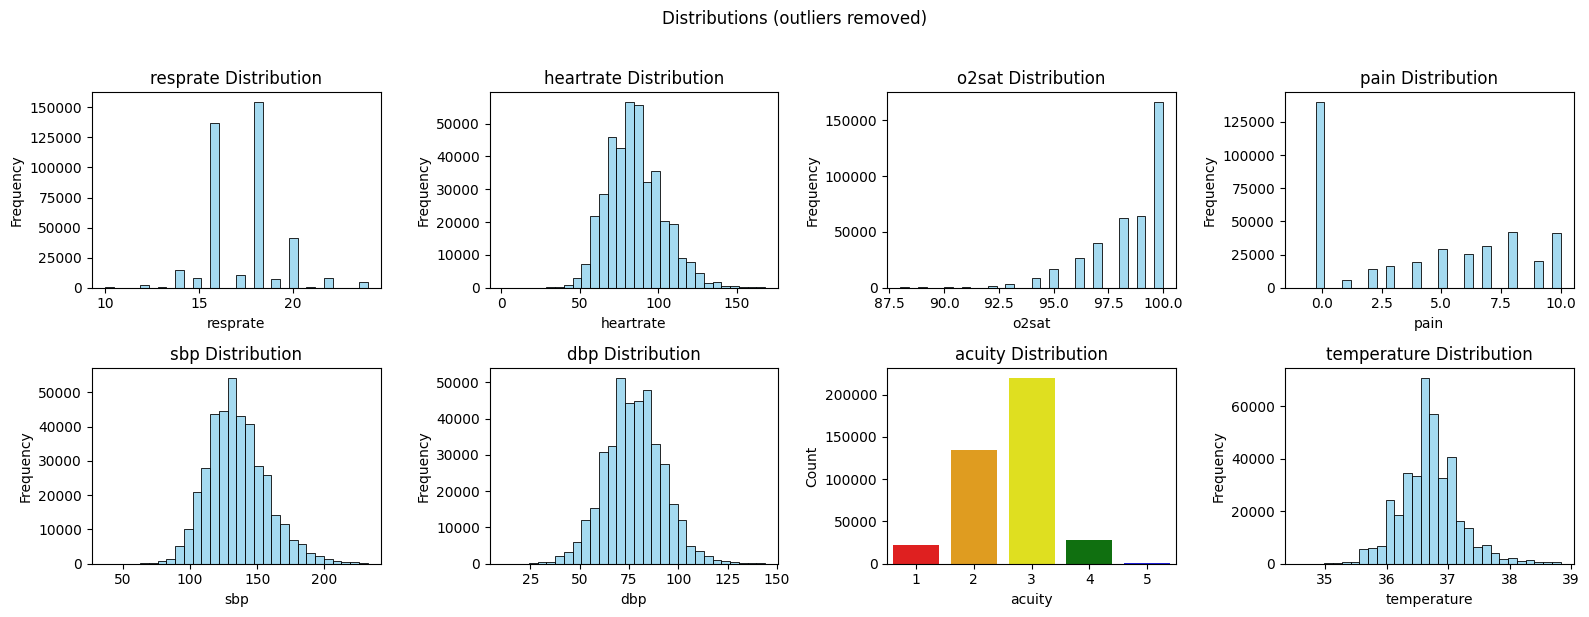

In [94]:
# Same distributions after trimming extreme values with 3*IQR.
_, _, _, numeric_plot_cols = get_plot_column_groups(df)

plot_numeric_distributions(
    dataframe=df,
    columns=numeric_plot_cols,
    target_col="acuity",
    remove_outliers=True,
    outlier_k=3.0,
    bins=30,
    cols_per_row=4,
)

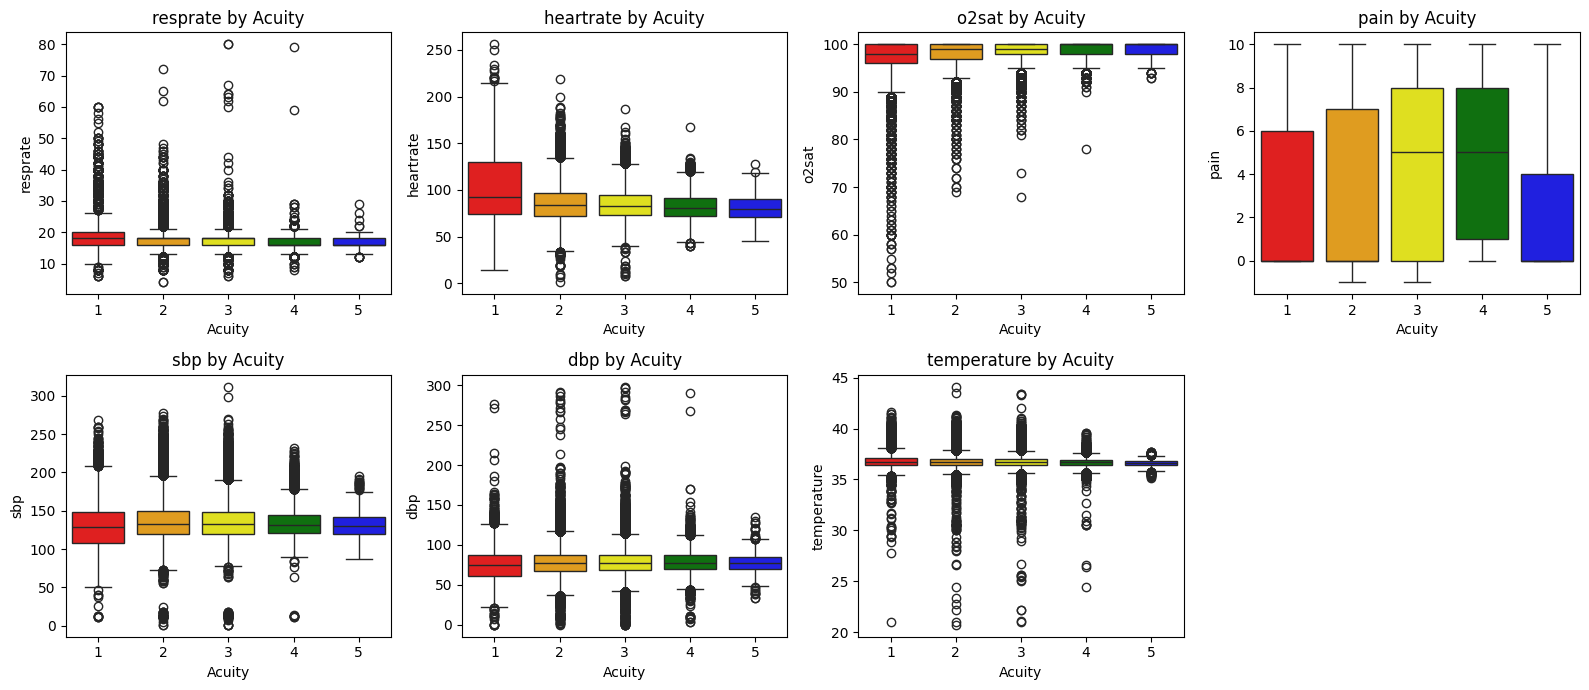

In [95]:
# Boxplots by acuity (target is excluded from y-axis variables).
_, _, _, numeric_plot_cols = get_plot_column_groups(df)

plot_boxplots_by_target(
    dataframe=df,
    value_cols=numeric_plot_cols,
    target_col="acuity",
    remove_outliers=False,
    n_cols=4,
)

## Missing Data Matrix

TODO 
- [ ] decidir se imputa ou drop
- [ ] se imputa, como?

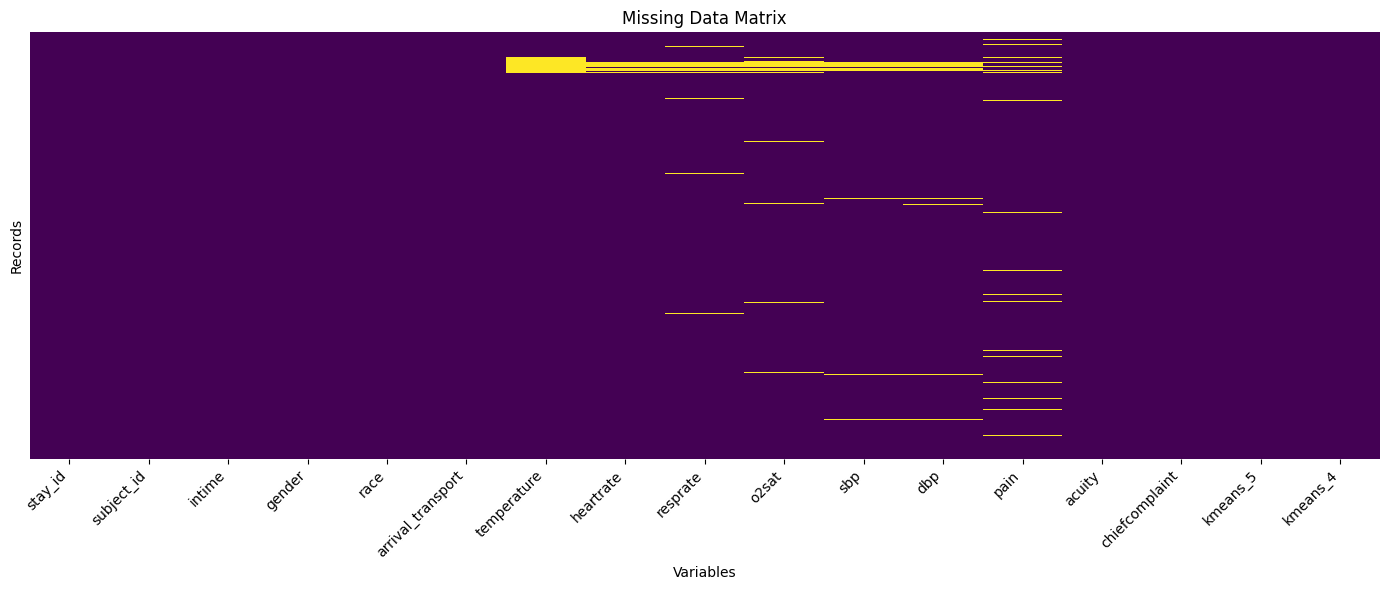

Missing values by column (%):
pain                 5.24
temperature          3.82
o2sat                3.21
resprate             3.14
dbp                  2.87
sbp                  2.68
heartrate            2.39
chiefcomplaint       0.00
stay_id              0.00
arrival_transport    0.00
intime               0.00
gender               0.00
race                 0.00
subject_id           0.00
acuity               0.00
kmeans_5             0.00
kmeans_4             0.00
dtype: float64


In [108]:
# Missing data matrix
missing_matrix = df.isna()

plt.figure(figsize=(14, 6))
sns.heatmap(missing_matrix, cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing Data Matrix")
plt.xlabel("Variables")
plt.ylabel("Records")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

missing_pct = (missing_matrix.mean() * 100).sort_values(ascending=False)
print("Missing values by column (%):")
print(missing_pct.round(2))

if (missing_pct == 0).all():
    print("\nNo missing values detected.")

## Correlation Matrix

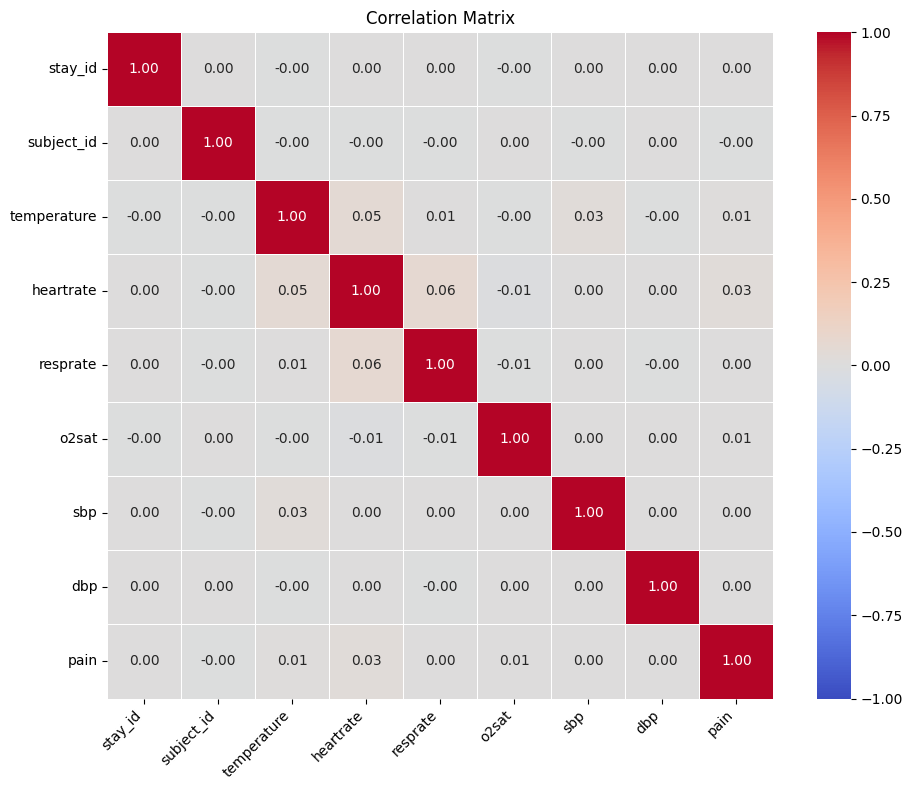

In [ ]:
# Correlation matrix (numeric variables only)
numeric_df = df.select_dtypes(include=["number"]).copy()

if numeric_df.shape[1] < 2:
    print("Not enough numeric columns to build a correlation matrix.")
else:
    corr_matrix = numeric_df.corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        corr_matrix,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        linewidths=0.5,
        square=True,
    )
    plt.title("Correlation Matrix")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

## KMeans Clustering (k=5)

Features used for clustering: ['temperature', 'resprate', 'heartrate', 'o2sat', 'pain', 'sbp', 'dbp']

Cluster counts:
kmeans_5
0     84955
1     43827
2    105911
3     47686
4    123445
Name: count, dtype: Int64


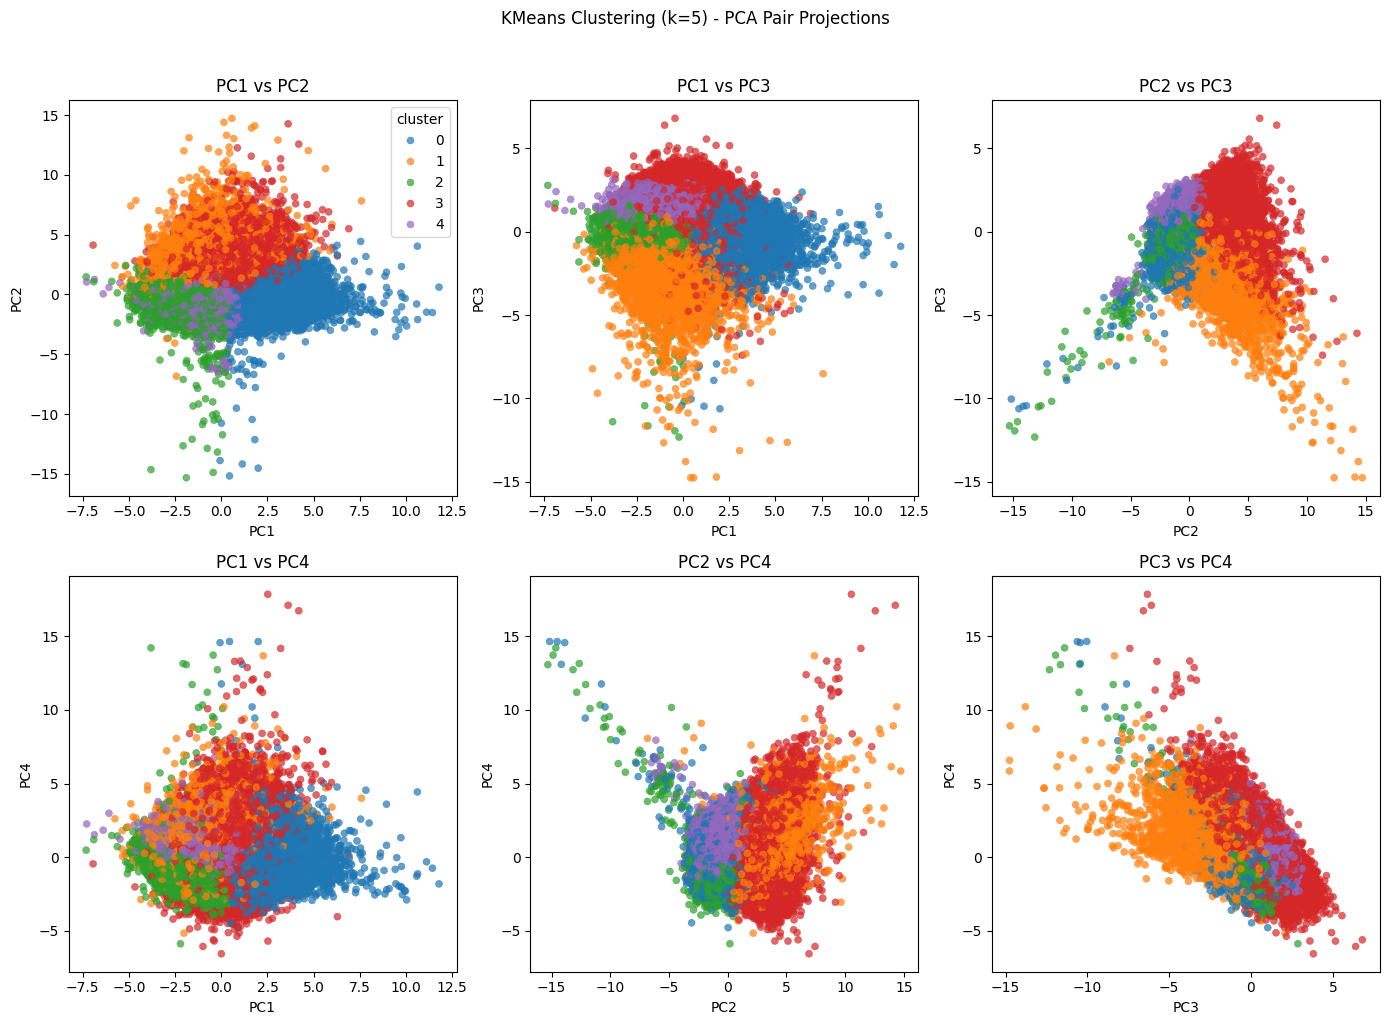

In [106]:
# KMeans with 5 clusters using numeric clinical variables.
N_CLUSTERS = 5

cluster_features = [
    col for col in (continuous_columns + int_columns)
    if col in df.columns
]

X = df[cluster_features].copy()

# Impute missing values and scale features.
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Train KMeans.
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=SEED, n_init=20)
clusters = kmeans.fit_predict(X_scaled)

# Save cluster labels.
cluster_col = f"kmeans_{N_CLUSTERS}"
df[cluster_col] = pd.Series(clusters, index=df.index).astype("Int64")

print("Features used for clustering:", cluster_features)
print("\nCluster counts:")
print(df[cluster_col].value_counts().sort_index())

# PCA projection with 5 components.
pca = PCA(n_components=5, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

plot_df = pd.DataFrame(
    {
        "PC1": X_pca[:, 0],
        "PC2": X_pca[:, 1],
        "PC3": X_pca[:, 2],
        "PC4": X_pca[:, 3],
        "PC5": X_pca[:, 4],
        "cluster": clusters,
    }
)

# Compare cluster separation across different PCA pairs.
pc_pairs = [("PC1", "PC2"), ("PC1", "PC3"), ("PC2", "PC3"), ("PC1", "PC4"), ("PC2", "PC4"), ("PC3", "PC4")]
fig, axes = plt.subplots(2, 3, figsize=(14, 10))
axes = axes.flatten()

for ax, (x_pc, y_pc) in zip(axes, pc_pairs):
    sns.scatterplot(
        data=plot_df,
        x=x_pc,
        y=y_pc,
        hue="cluster",
        palette="tab10",
        alpha=0.7,
        s=25,
        edgecolor=None,
        legend="full" if (x_pc, y_pc) == pc_pairs[0] else False,
        ax=ax,
    )
    ax.set_title(f"{x_pc} vs {y_pc}")
    ax.set_xlabel(x_pc)
    ax.set_ylabel(y_pc)

plt.suptitle(f"KMeans Clustering (k={N_CLUSTERS}) - PCA Pair Projections", y=1.02)
plt.tight_layout()
plt.show()

In [102]:
#correlation of cluster labels with acuity
if "acuity" in df.columns:
    valid_rows = df[["kmeans_5", "acuity"]].dropna()
    if not valid_rows.empty:
        kmeans_labels = valid_rows["kmeans_5"].astype(int)
        acuity_values = valid_rows["acuity"].astype(int)

        pearson_corr, pearson_p = pearsonr(kmeans_labels, acuity_values)
        spearman_corr, spearman_p = spearmanr(kmeans_labels, acuity_values)

        print(f"Pearson correlation between KMeans clusters and acuity: {pearson_corr:.3f} (p={pearson_p:.3e})")
        print(f"Spearman correlation between KMeans clusters and acuity: {spearman_corr:.3f} (p={spearman_p:.3e})")
    else:
        print("No valid rows with both KMeans labels and acuity for correlation.")

Pearson correlation between KMeans clusters and acuity: 0.063 (p=0.000e+00)
Spearman correlation between KMeans clusters and acuity: 0.087 (p=0.000e+00)


In [107]:
# PCA diagnostics for interpretation
explained_ratio = pca.explained_variance_ratio_
cumulative_ratio = explained_ratio.cumsum()

print("Explained variance ratio:")
for i, ratio in enumerate(explained_ratio, start=1):
    print(f"PC{i}: {ratio:.4f}")

print(f"\nCumulative explained variance (PC1+PC2): {cumulative_ratio[1]:.4f}")

print(f"\nCumulative explained variance (PC1+PC2+PC3): {cumulative_ratio[2]:.4f}")

print(f"\nCumulative explained variance (PC1+PC2+PC3+PC4): {cumulative_ratio[3]:.4f}")

print(f"\nCumulative explained variance (PC1+PC2+PC3+PC4+PC5): {cumulative_ratio[4]:.4f}")



loadings = pd.DataFrame(
    pca.components_.T,
    index=cluster_features,
    columns=["PC1", "PC2", "PC3", "PC4", "PC5"][:pca.n_components_],
)

print("\nPCA loadings:")
print(loadings.round(4))

print("\nTop contributors to PC1 (absolute loading):")
print(loadings["PC1"].abs().sort_values(ascending=False).head(5).round(4))

print("\nTop contributors to PC2 (absolute loading):")
print(loadings["PC2"].abs().sort_values(ascending=False).head(5).round(4))

print("\nTop contributors to PC3 (absolute loading):")
print(loadings["PC3"].abs().sort_values(ascending=False).head(5).round(4))

print("\nTop contributors to PC4 (absolute loading):")
print(loadings["PC4"].abs().sort_values(ascending=False).head(5).round(4))

print("\nTop contributors to PC5 (absolute loading):")
print(loadings["PC5"].abs().sort_values(ascending=False).head(5).round(4))

centers_pca = pca.transform(kmeans.cluster_centers_)
centers_pca_df = pd.DataFrame(centers_pca, columns=["PC1", "PC2", "PC3", "PC4", "PC5"][:pca.n_components_])
centers_pca_df.index.name = "cluster"
print("\nCluster centers projected on PCA space:")
print(centers_pca_df.round(3))

Explained variance ratio:
PC1: 0.2194
PC2: 0.1888
PC3: 0.1569
PC4: 0.1332
PC5: 0.1222

Cumulative explained variance (PC1+PC2): 0.4082

Cumulative explained variance (PC1+PC2+PC3): 0.5652

Cumulative explained variance (PC1+PC2+PC3+PC4): 0.6984

Cumulative explained variance (PC1+PC2+PC3+PC4+PC5): 0.8206

PCA loadings:
                PC1     PC2     PC3     PC4     PC5
temperature -0.0050  0.4951  0.3888 -0.4866 -0.1955
resprate     0.1174  0.4753 -0.2329  0.6094  0.4118
heartrate    0.2319  0.5691  0.2413 -0.1290  0.2643
o2sat        0.0607 -0.4158  0.5163 -0.0902  0.7124
pain         0.1399 -0.0571  0.6541  0.5922 -0.4411
sbp          0.6492 -0.1525 -0.2032 -0.0953 -0.1421
dbp          0.6983 -0.0760 -0.0251 -0.0853  0.0002

Top contributors to PC1 (absolute loading):
dbp          0.6983
sbp          0.6492
heartrate    0.2319
pain         0.1399
resprate     0.1174
Name: PC1, dtype: float64

Top contributors to PC2 (absolute loading):
heartrate      0.5691
temperature    0.4951
res

Correlation with acuity (coefficient, p-value) after removing extreme outliers (k=3*IQR):
PC1 vs acuity | Pearson r=0.0004, p=7.8282e-01 | Spearman rho=-0.0013, p=4.0935e-01 | removed=257
PC2 vs acuity | Pearson r=-0.0124, p=7.8853e-15 | Spearman rho=-0.0078, p=1.1200e-06 | removed=2200
PC3 vs acuity | Pearson r=0.0005, p=7.6203e-01 | Spearman rho=-0.0013, p=4.0981e-01 | removed=390
PC4 vs acuity | Pearson r=-0.0009, p=5.7593e-01 | Spearman rho=-0.0005, p=7.4881e-01 | removed=827
PC5 vs acuity | Pearson r=-0.0209, p=2.1948e-39 | Spearman rho=-0.0203, p=4.6813e-37 | removed=975


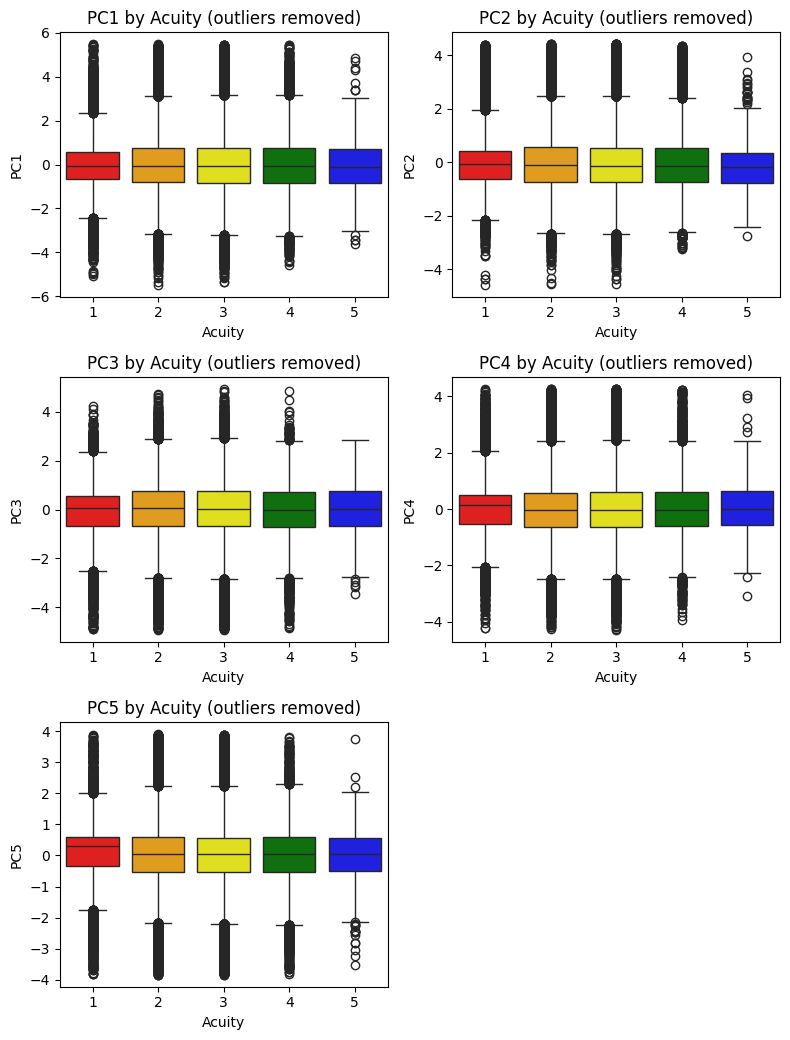

In [101]:
# Correlation between PCA components and acuity (with p-values), excluding extreme outliers per PC.

pca_acuity_df = plot_df.copy()
pca_acuity_df["acuity"] = pd.to_numeric(df["acuity"], errors="coerce")

pc_columns = [col for col in ["PC1", "PC2", "PC3", "PC4", "PC5"] if col in pca_acuity_df.columns]
if not pc_columns:
    raise ValueError("No PCA component columns were found in plot_df.")

print("Correlation with acuity (coefficient, p-value) after removing extreme outliers (k=3*IQR):")
for pc in pc_columns:
    valid_df = pca_acuity_df.dropna(subset=[pc, "acuity"]).copy()
    filtered_df = remove_extreme_outliers_iqr(valid_df, pc, k=3.0)
    n_removed = len(valid_df) - len(filtered_df)

    if filtered_df.empty or filtered_df[pc].nunique() < 2 or filtered_df["acuity"].nunique() < 2:
        print(f"{pc}: skipped after filtering (insufficient variation). Removed={n_removed}")
        continue

    pearson_r, pearson_p = pearsonr(filtered_df[pc], filtered_df["acuity"])
    spearman_r, spearman_p = spearmanr(filtered_df[pc], filtered_df["acuity"])
    print(
        f"{pc} vs acuity | Pearson r={pearson_r:.4f}, p={pearson_p:.4e} "
        f"| Spearman rho={spearman_r:.4f}, p={spearman_p:.4e} "
        f"| removed={n_removed}"
    )

plot_boxplots_by_target(
    dataframe=pca_acuity_df,
    value_cols=pc_columns,
    target_col="acuity",
    remove_outliers=True,
    outlier_k=3.0,
    n_cols=2,
    title_suffix="by Acuity (outliers removed)",
)